<a href="https://colab.research.google.com/github/pedrohcmg1/Ativida-Dacio/blob/main/Trabalho_Munif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/1ay2nOuofGz3xPcndKkR--hStjd7iHCN4EPAQsyNi6E8/export?format=csv&gid=0"

df = pd.read_csv(url)

print("Colunas lidas:", list(df.columns))
print(df.head())

Colunas lidas: ['id', 'cidade', 'bairro_classe', 'tamanho_m2', 'quartos', 'banheiros', 'vagas_garagem', 'ano_construcao', 'tem_energia_solar', 'tem_automacao', 'distancia_centro_km', 'indice_criminalidade', 'renda_media_regiao', 'avaliacao_escolas', 'preco_venda']
   id         cidade bairro_classe  tamanho_m2  quartos  banheiros  \
0   1      São Paulo          Alta         220        4          3   
1   2       Curitiba         Média         140        3          2   
2   3         Recife         Baixa          90        2          1   
3   4  Florianópolis          Alta         260        4          4   
4   5        Goiânia         Média         160        3          2   

   vagas_garagem  ano_construcao tem_energia_solar tem_automacao  \
0              3            2018               Sim           Sim   
1              2            2015               Não           Sim   
2              1            2008               Não           Não   
3              3            2020          

In [ ]:
FEATURES = [
    "tamanho_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "ano_construcao",
    "distancia_centro_km",
    "indice_criminalidade",
    "renda_media_regiao",
    "avaliacao_escolas"
]

TARGET = "preco_venda"

# Converte colunas numéricas
for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

# Remove linhas inválidas
df = df.dropna(subset=FEATURES + [TARGET]).copy()

print("\nDistribuição do target:")
print(df[TARGET].describe())



Distribuição do target:
count    1.000000e+02
mean     1.213500e+06
std      6.343459e+05
min      2.700000e+05
25%      7.950000e+05
50%      1.020000e+06
75%      1.512500e+06
max      3.500000e+06
Name: preco_venda, dtype: float64


In [ ]:
X_all = df[FEATURES].values
y_all = df[TARGET].values

print("Total linhas válidas:", len(df))
print("Formato X:", X_all.shape)
print("Formato y:", y_all.shape)

Total linhas válidas: 100
Formato X: (100, 9)
Formato y: (100,)


In [ ]:

RANDOM_STATE = 42

df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

limite_teste = int(len(df) * 0.20)

test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:].copy()

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values

X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

print("\nTreino:", len(train_df), "| Teste:", len(test_df))



Treino: 80 | Teste: 20


In [ ]:
def dist_preco(frame, target_col, titulo):
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    print(frame[target_col].describe())

dist_preco(df, TARGET, "Dataset completo")
dist_preco(train_df, TARGET, "Treino")
dist_preco(test_df, TARGET, "Teste")


=== Dataset completo (n=100) ===
count    1.000000e+02
mean     1.213500e+06
std      6.343459e+05
min      2.700000e+05
25%      7.950000e+05
50%      1.020000e+06
75%      1.512500e+06
max      3.500000e+06
Name: preco_venda, dtype: float64

=== Treino (n=80) ===
count    8.000000e+01
mean     1.175750e+06
std      6.070447e+05
min      2.700000e+05
25%      7.950000e+05
50%      9.800000e+05
75%      1.500000e+06
max      3.500000e+06
Name: preco_venda, dtype: float64

=== Teste (n=20) ===
count    2.000000e+01
mean     1.364500e+06
std      7.310877e+05
min      2.800000e+05
25%      8.100000e+05
50%      1.435000e+06
75%      1.737500e+06
max      3.200000e+06
Name: preco_venda, dtype: float64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

K = 5
WEIGHTS = "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsRegressor(weights='distance'))])

In [ ]:
# Avaliação

nova_casa = pd.DataFrame(
    [[120,   # tamanho_m2
      3,     # quartos
      2,     # banheiros
      2,     # vagas_garagem
      2015,  # ano_construcao
      8,     # distancia_centro_km
      0.3,   # indice_criminalidade
      5000,  # renda_media_regiao
      7.5    # avaliacao_escolas
    ]],
    columns=FEATURES
)

model.predict(nova_casa)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


array([863253.2281196])

In [ ]:
# Resultado detalhado do teste
test_df["classe_prevista"] = le.inverse_transform(y_pred)
display(test_df[["cidade"] + FEATURES + ["temp_media_c", TARGET, "classe_prevista"]])

,cidade,latitude,longitude,altitude_m,temp_media_c,clima,classe_prevista
0,Fortaleza,-3.725408,-38.523614,27,26.6,quente,ameno
1,Goiânia,-16.680228,-49.256453,750,23.2,frio,frio
2,Teresina,-5.091108,-42.811614,73,27.1,quente,quente
3,Florianópolis,-27.597500,-48.549700,3,20.4,frio,frio
4,Porto Velho,-8.749375,-63.910625,85,25.6,ameno,quente


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 138958.14965626452
RMSE: 263405.0534928049



=== Árvore de decisão (Regressão) ===
Features usadas: ['tamanho_m2', 'quartos', 'banheiros', 'vagas_garagem', 'ano_construcao', 'distancia_centro_km', 'indice_criminalidade', 'renda_media_regiao', 'avaliacao_escolas']
MAE: 136285.55900621117
RMSE: 235255.30272383915
R2: 0.891002560812492


,tamanho_m2,quartos,banheiros,vagas_garagem,ano_construcao,distancia_centro_km,indice_criminalidade,renda_media_regiao,avaliacao_escolas,preco_venda,preco_previsto_arvore
0,145,3,2,2,2016,13,4.9,5100,6.7,700000,7.839286e+05
1,210,4,3,3,2020,6,2.4,9400,8.6,1650000,1.507391e+06
2,210,4,3,3,2019,7,2.8,8800,8.2,1480000,1.507391e+06
3,220,4,3,3,2020,6,2.2,9300,8.8,1700000,1.507391e+06
4,88,2,1,1,2008,19,6.8,2700,5.3,280000,2.960000e+05
5,260,4,4,3,2022,4,1.6,12500,9.3,3200000,3.500000e+06
6,88,2,1,1,2007,21,7.0,3000,5.6,290000,2.960000e+05
7,180,3,3,2,2019,8,2.1,11500,9.0,1900000,1.050000e+06
8,280,4,4,3,2019,5,2.3,11000,8.7,2400000,2.025000e+06
9,220,4,3,3,2018,8,2.1,9500,8.9,1850000,2.025000e+06


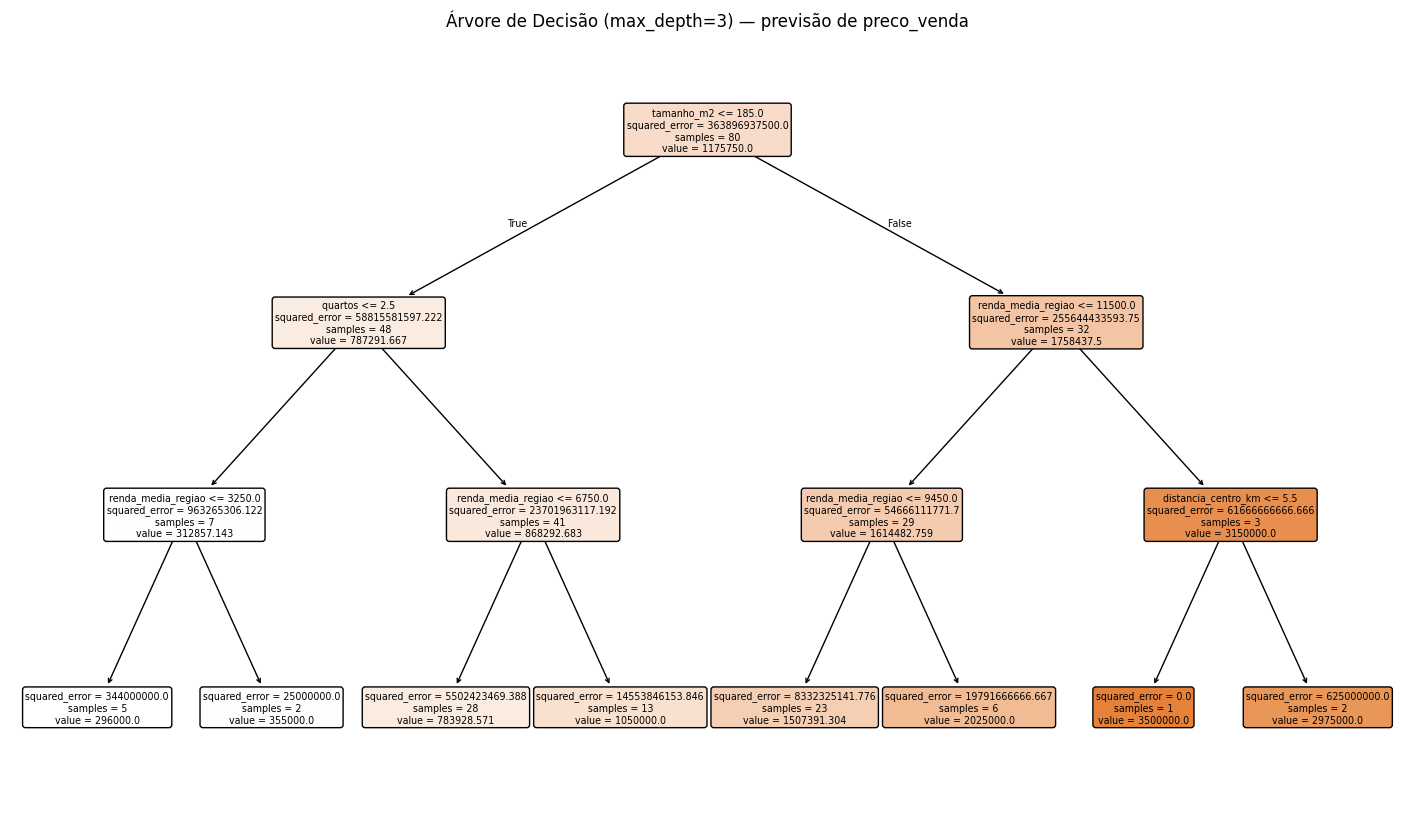

In [ ]:
# ========= Árvore de decisão (REGRESSÃO para preco_venda) =========
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

tree = DecisionTreeRegressor(
    max_depth=3,        # controla complexidade
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão (Regressão) ===")
print("Features usadas:", FEATURES)

mae = mean_absolute_error(y_test, y_pred_tree)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2 = r2_score(y_test, y_pred_tree)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# Resultado detalhado
test_df["preco_previsto_arvore"] = y_pred_tree
display(test_df[FEATURES + [TARGET, "preco_previsto_arvore"]])

# desenhar a árvore
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    filled=True,
    rounded=True
)
plt.title("Árvore de Decisão (max_depth=3) — previsão de preco_venda")
plt.show()